In [26]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np

test_perc=60

testFull = "TestFull.csv"
testMiss = f"TestMiss_{test_perc}.0pct.csv"
testBeagleOutput = f"beagle/outBeagle_TestMiss_{test_perc}.0pct.csv"

outfile = "beagle/evaluation.csv"
file_exists = os.path.isfile(outfile)

outfileMAF = "beagle/MAF_evaluation.csv"
file_existsMAF = os.path.isfile(outfileMAF)

In [18]:
# load files
test = pd.read_csv(testMiss)            # original with 3 = missing
truth = pd.read_csv(testFull)           # full ground truth
pred = pd.read_csv(testBeagleOutput)    # beagle output

mask = test.values == 3
y_true = truth.values[mask].flatten()
y_pred = pred.values[mask].flatten()

confusion matrix (rows=true, cols=pred):
 [[41663   767    76]
 [ 3622  5789   994]
 [  123   166  2670]]


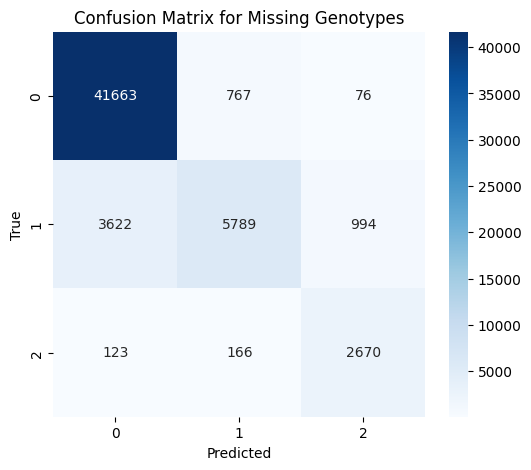

In [19]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
print("confusion matrix (rows=true, cols=pred):\n", cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Missing Genotypes")
plt.show()


In [20]:
tp_per_class = cm.diagonal()
print("true positives per class:", tp_per_class)

true positives per class: [41663  5789  2670]


In [21]:
# accuracy
acc = accuracy_score(y_true, y_pred)
print("accuracy:", acc)

# f1 micro
f1_micro = f1_score(y_true, y_pred, average="micro")
print("f1 micro:", f1_micro)

# f1 macro
f1_macro = f1_score(y_true, y_pred, average="macro")
print("f1 macro:", f1_macro)

# per class
f1_per_class = f1_score(y_true, y_pred, labels=[0,1,2], average=None)
print("f1 per class (0,1,2):", f1_per_class)

accuracy: 0.8971183103633434
f1 micro: 0.8971183103633434
f1 macro: 0.8069850589946412
f1 per class (0,1,2): [0.94781264 0.67600864 0.7971339 ]


In [22]:
print(classification_report(
    y_true,
    y_pred,
    labels=[0,1,2],
    target_names=["genotype_0", "genotype_1", "genotype_2"],
    digits=4
))

              precision    recall  f1-score   support

  genotype_0     0.9175    0.9802    0.9478     42506
  genotype_1     0.8612    0.5564    0.6760     10405
  genotype_2     0.7139    0.9023    0.7971      2959

    accuracy                         0.8971     55870
   macro avg     0.8309    0.8130    0.8070     55870
weighted avg     0.8963    0.8971    0.8892     55870



In [7]:
# save
import csv
from datetime import datetime

row = [datetime.now().strftime("%Y-%m-%d %H:%M:%S"), testMiss, 
       f1_micro, f1_macro,
       f1_per_class[0], f1_per_class[1], f1_per_class[2]]

with open(outfile, 'a', newline='') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(["date","dataset","f1_micro", "f1_macro", "f1_0","f1_1","f1_2"])
    writer.writerow(row)

print(f"Appended F1 scores to {outfile}")

Appended F1 scores to beagle/evaluation.csv


In [35]:
from pathlib import Path


def read_maf(maf_path: str):
    """Read MAF CSV, drop last column, return float64 array."""
    p = Path(maf_path)
    if not p.exists():
        print(f"[ERROR] File not found: {maf_path}")
        return None

    try:
        if p.suffix == ".csv":
            # assume CSV already contains [freq_major, freq_minor]
            dataMAF = pd.read_csv(p, header=None)
            dataMAF = dataMAF.drop(dataMAF.columns[-1], axis=1)
            dataMAF = dataMAF.values.astype(np.float64)

        elif p.suffix == ".afreq":
            # PLINK .afreq: whitespace-separated, columns = #CHROM	ID	REF	ALT	PROVISIONAL_REF?	ALT_FREQS	OBS_CT
            data = pd.read_csv(p, header=0, delim_whitespace=True)  # has column names
            # compute freq_major and freq_minor
            alt_freq = data['ALT_FREQS'].values.astype(np.float64) 
            freq_minor = alt_freq
            freq_major = 1.0 - alt_freq
            dataMAF = np.column_stack((freq_major, freq_minor))
        else:
            raise ValueError(f"Unsupported file type: {p.suffix}")

        print(f"[INFO] Loaded MAF '{maf_path}' shape {dataMAF.shape}")
        return dataMAF
    
    except Exception as e:
        print(f"[ERROR] Failed to read MAF: {e}")
        return None
dataMAF = read_maf("../MAF/TestFull_maf.afreq")

[INFO] Loaded MAF '../MAF/TestFull_maf.afreq' shape (500, 2)


C:\Users\weraz\AppData\Local\Temp\ipykernel_25524\3810461412.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(p, header=0, delim_whitespace=True)  # has column names


In [ ]:
def compute_masked_maf(dataMAF, mask_miss, maf_threshold=0.05):
    """
    Compute rare SNP flags.
    dataMAF[i] = [freq_major, freq_minor] for SNP i.
    mask_miss = binary mask (1 if SNP i is masked/missing, 0 if not)
                can be np.ndarray (batch x snps) or nested list
    maf_threshold = cutoff for rare
    Returns: np.ndarray of shape (n_snps, 2) -> [p_min, is_rare]
    """
    # --- DEBUG
    mask_miss = tf.convert_to_tensor(mask_miss, dtype=tf.float32)
    mask_flat = tf.reshape(mask_miss[0], [-1])  # shape (1, n_snps)

    p = np.sum(dataMAF * mask_flat.numpy()[:, None], axis=1)
    p_min = np.min(dataMAF, axis=1)
    valid_mask = p > 0
    p_min_valid = p_min[valid_mask]
    is_rare = (p_min_valid <= maf_threshold).astype(int)

    mafMISS = np.column_stack((p_min_valid, is_rare))
    return mafMISS


def maf_stratified_metrics(trueMISS, discrete_predict, dataMAF, mask_missing, maf_threshold=0.05):
    """
    Compute genotype performance stratified by MAF threshold.
    Returns a dict: {0: common_metrics, 1: rare_metrics}
    """
    # --- ensure numpy arrays
    trueMISS = np.array(trueMISS)
    discrete_predict = np.array(discrete_predict)
    dataMAF = np.array(dataMAF)

    maf_groups = compute_masked_maf(dataMAF, mask_missing, maf_threshold)
    rare_flags = maf_groups[:, 1]

    n_individuals = len(trueMISS) // len(rare_flags)
    if len(trueMISS) % len(rare_flags) != 0:
        raise ValueError(f"trueMISS length ({len(trueMISS)}) not divisible by SNP count ({len(rare_flags)}).")

    rare_flags_full = np.tile(rare_flags, n_individuals)

    results = {}
    for label, desc in zip([0, 1], ["Common", "Rare"]):
        mask = rare_flags_full == label
        t, p = trueMISS[mask], discrete_predict[mask]

        f1_micro = f1_score(t, p, average='micro', zero_division=0)
        f1_macro = f1_score(t, p, average='macro', zero_division=0)
        f1_per_class = f1_score(t, p, labels=[0,1,2], average=None, zero_division=0)
        report = classification_report(t, p, digits=3, output_dict=False, zero_division=0)
        cm = confusion_matrix(t, p, labels=[0,1,2])

        results[label] = {
            "desc": desc,
            "report": report,
            "f1_micro": f1_micro,
            "f1_macro": f1_macro,
            "f1_per_class": f1_per_class,
            "confusion_matrix": cm
        }
    return results

In [36]:
def save_maf_metrics(metrics):
    """
    Save rare SNP metrics to CSV and print nicely.
    """
    # take rare SNP metrics (key=1)
    rare_metrics = metrics[1]

    print(f"Description: {rare_metrics['desc']}\n")
    print("Classification Report:\n")
    print(rare_metrics['report'])
    print(f"F1 (micro): {rare_metrics['f1_micro']:.4f}")
    print(f"F1 (macro): {rare_metrics['f1_macro']:.4f}")
    print(f"F1 per class [0,1,2]: {rare_metrics['f1_per_class']}")
    print("Confusion Matrix:\n", rare_metrics['confusion_matrix'])

    # write to CSV
    with open(outfileMAF, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_existsMAF:
            writer.writerow([
                "model", "model_path", "date", "dataset", "f1_micro", "f1_macro",
                "f1_0", "f1_1", "f1_2"
            ])
        writer.writerow([
            "Beagle", "",  datetime.now().strftime("%Y-%m-%d %H:%M:%S"), testMiss,
            rare_metrics['f1_micro'], rare_metrics['f1_macro'],
            rare_metrics['f1_per_class'][0], rare_metrics['f1_per_class'][1], rare_metrics['f1_per_class'][2]
        ])

    print(f"Appended F1 scores to {outfileMAF}")

In [39]:
metrics = maf_stratified_metrics(y_true, y_pred, dataMAF, mask)
save_maf_metrics(metrics)

[DEBUG] Type of mask_miss before processing: <class 'numpy.ndarray'>
[DEBUG] Shape of mask_miss after flattening: (185, 500)


IndexError: boolean index did not match indexed array along dimension 0; dimension is 500 but corresponding boolean dimension is 2